In [2]:
import pandas as pd
import os
file_path = r'data\rawData'
txt_file_path = r'data\processedData'
new_path = r'd:\Desktop\PHD\reasearch\biyework\maml'
os.chdir(new_path)
# 检查当前路径是否切换成功
current_path = os.getcwd()
print(current_path)

d:\Desktop\PHD\reasearch\biyework\maml


In [8]:

all_data_new_fit_csv=r"data\processedData\FLOOR3\all_data_new_fit.csv"
location_vector_csv = r"model\v1\output\location_vector_v3.csv"

df=pd.read_csv(all_data_new_fit_csv)    
df_location = pd.read_csv(location_vector_csv)

# 1. 每个 location_id 在不同 sf 情况下的 average_rssi 和 snr 的均值和方差
location_sf_stats = df.groupby(['location_id', 'sf']).agg(
    serial_average_rssi_mean=('average_rssi', 'mean'),
    serial_average_rssi_var=('average_rssi', 'var'),
    snr_mean=('snr', 'mean'),
    # snr_var=('snr', 'var'),
    # serial_var=('rssi_variance', 'var'),
    serial_mean=('rssi_variance', 'mean'),
).reset_index()


# 2. 每个 sf 在不同 location_id 情况下的 average_rssi 和 snr 的均值和方差
sf_location_stats = df.groupby(['sf', 'location_id']).agg(
    serial_average_rssi_mean=('average_rssi', 'mean'),
    serial_average_rssi_var=('average_rssi', 'var'),
    snr_mean=('snr', 'mean'),
    # snr_var=('snr', 'var'),
    # serial_var=('rssi_variance', 'var'),
    serial_var_mean=('rssi_variance', 'mean'),
).reset_index()

# 确保 location_id 的数据类型一致
location_sf_stats['location_id'] = location_sf_stats['location_id'].astype(str)
sf_location_stats['location_id'] = sf_location_stats['location_id'].astype(str)
df_location['location_id'] = df_location['location_id'].astype(str)

# 合并 distance_true 信息到 location_sf_stats
location_sf_stats = pd.merge(location_sf_stats, df_location[['location_id', 'distance_true']], on='location_id', how='left')

# 合并 distance_true 信息到 sf_location_stats
sf_location_stats = pd.merge(sf_location_stats, df_location[['location_id', 'distance_true']], on='location_id', how='left')

# 保存
location_sf_stats.to_csv(r"data\processedData\FLOOR3\location_sf_stats.csv", index=False)
sf_location_stats.to_csv(r"data\processedData\FLOOR3\sf_location_stats.csv", index=False)


In [3]:
# 计算平均值
data=[-55,-48,-50,-51,-55,-52,-51,-48,-50,-48,-59,-48,-48,-50,-49,-53,-52,-57,-48,-48,-49,-48,-50,-48,-47,-52,-49,-48,-49]
average = sum(data) / len(data)
print("平均值:", average)

平均值: -50.3448275862069


tsne数据分布可视化

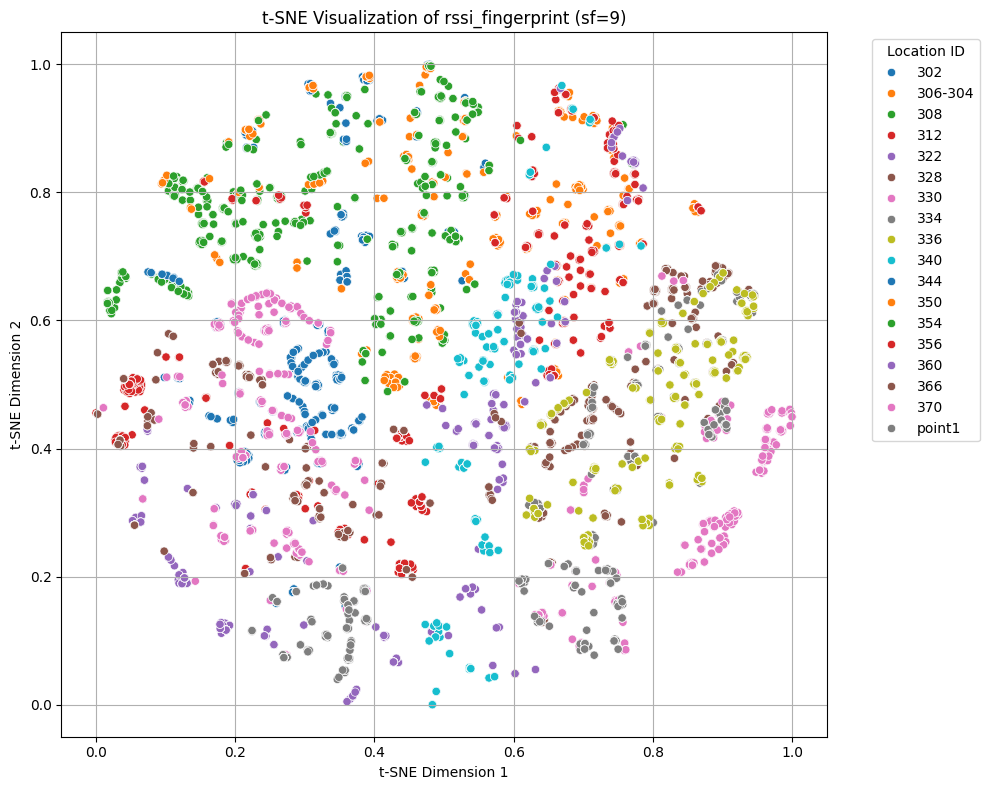

In [23]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
# t-sne的输入数据需要是（batch_size,features_dim）的形式
# 1. 读取数据
file_path = r"data\processedData\FLOOR3\all_data_new.csv"  # 替换为实际文件路径
location_vector_csv = r"model\v1\output\location_vector_v3.csv"  # 替换为实际文件路径

location_vector = pd.read_csv(location_vector_csv)
data = pd.read_csv(file_path)
sf=9
# 2. 筛选出 sf=sf 的数据
sf_data = data[data['sf']== sf]
# location_list=["point1","370","360","350","336","1m","328","308"]
# 读取 location_vector 数据
sf_data = sf_data[sf_data['location_id'].isin(location_vector['location_id'])]
# sf_data = sf_data[sf_data['location_id'].isin(location_list)]

features = sf_data[['average_rssi', 'snr','rssi']].values

tsne = TSNE(n_components=2, random_state=42,perplexity=30, max_iter=1000, learning_rate=200)
tsne_results = tsne.fit_transform(features)

# 将降维结果添加到数据框中
sf_data['tsne_1'] = tsne_results[:, 0]
sf_data['tsne_2'] = tsne_results[:, 1]
#   归一化
sf_data['tsne_1'] = (sf_data['tsne_1'] - sf_data['tsne_1'].min()) / (sf_data['tsne_1'].max() - sf_data['tsne_1'].min())
sf_data['tsne_2'] = (sf_data['tsne_2'] - sf_data['tsne_2'].min()) / (sf_data['tsne_2'].max() - sf_data['tsne_2'].min())
# 4. 可视化
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='tsne_1', y='tsne_2', 
    hue='location_id', 
    palette='tab10', 
    data=sf_data, 
    legend="full"
)
plt.title("t-SNE Visualization of rssi_fingerprint (sf={})".format(sf))
plt.grid(True)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title='Location ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()